# 2.1 — Базовые модели (MLP, GRU, TCN)

**Папка 2 «Обучение моделей», подноутбук 1.** Для каждой базовой модели выполняется
**подбор гиперпараметров перебором по сетке (grid search)** с богатой историей (все метрики
по каждой конфигурации). Метрика отбора выбирается явно. Лучшая комбинация сохраняется в
`models/<имя>/hyperparams.json`, после чего финальное обучение **читает этот JSON** и обучает
модель «начисто» с отслеживанием метрик. Рисунки и таблицы — на английском.

## Окружение и данные

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "demo_run"
MODELS_DIR = REPO_ROOT / "models"

import torch

from liquefaction_ai import load_population_artifact, prepare_benchmark_dataset, train_model
from liquefaction_ai.training import grid_search, write_hyperparams, read_hyperparams, save_trained_model
from liquefaction_ai.evaluation import METRICS, english_metric_table, metrics_catalog, subsample_split
from liquefaction_ai.viz import grid_search_dashboard, training_dashboard, lines

population, config = load_population_artifact(DATA_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
benchmark = prepare_benchmark_dataset(population, config, device)
static_dim = benchmark["train"]["static"].shape[1]
prefix_dim = benchmark["train"]["prefix_summary"].shape[1]
seq_dim = benchmark["train"]["seq_in"].shape[-1]

# Grid search выполняется на компактной подвыборке (для ранжирования гиперпараметров).
gs_train = subsample_split(benchmark["train"], 2000, config.seed)
gs_val = subsample_split(benchmark["val"], 600, config.seed + 1)


def show_grid_dashboard(res, grid, score, metric_keys, fig_id):
    """Построить дашборд grid search: по Y — метрики, по X — текст конфигурации."""
    info = METRICS[score]
    labels = {k: f"{METRICS[k].name} ({METRICS[k].units})" for k in metric_keys}
    fmts = {k: METRICS[k].fmt for k in metric_keys}
    return grid_search_dashboard(res, metric_keys, list(grid.keys()), score,
                                 metric_labels=labels, metric_fmts=fmts,
                                 lower_is_better=info.lower_is_better, target=info.target,
                                 save=SAVE_FIGS, fig_id=fig_id)

print("device:", device, "| dims static/prefix/seq:", static_dim, prefix_dim, seq_dim)
from liquefaction_ai.models import (GRUBaseline, LSTMBaseline, RiskMLP, TCNBaseline,
                                    TransformerBaseline, FTTransformer, CatBoostBaseline,
                                    PINNBaseline, DeepStateBaseline, RealNVPFlow, NeuralSplineFlow)

device: cpu | dims static/prefix/seq: 34 6 5


## Каталог метрик

Все метрики качества определены с подробными описаниями в `liquefaction_ai.evaluation.metrics`
(`METRICS`) и импортируются в ноутбук. **Метрику отбора лучших гиперпараметров можно выбрать**
через переменную `SELECTION_METRIC` ниже.

In [2]:
display(metrics_catalog())

,Metric,Name,Units,Direction,Description
0,val_loss,Validation loss,–,lower is better,Mean validation value of the model's training ...
1,Traj_RMSE,Trajectory RMSE,–,lower is better,Root-mean-square error of the predicted pore-p...
2,Traj_MAE,Trajectory MAE,–,lower is better,Mean absolute error of the predicted PPR(N) tr...
3,Traj_MSE,Trajectory MSE,–,lower is better,Mean squared error of the predicted PPR(N) tra...
4,N_liq_MAE,MAE of N_liq,cycles,lower is better,Mean absolute error of the predicted number of...
5,AUROC,AUROC,–,higher is better,Area under the ROC curve for liquefaction-risk...
6,AUPRC,AUPRC,–,higher is better,Area under the precision–recall curve; classif...
7,Brier,Brier score,–,lower is better,Mean squared error of the predicted liquefacti...
8,ECE,Expected calibration error,–,lower is better,Average absolute gap between predicted confide...
9,Coverage_90,90% interval coverage,–,target ≈ 0.9,Empirical fraction of true PPR values that fal...


## Шаг 1. Grid search, история по всем метрикам и сохранение гиперпараметров

Для каждой модели задана своя метрика отбора `score` (можно менять). Дашборд показывает
все метрики по каждой конфигурации; лучшая по метрике отбора подсвечена.

[MLP-Risk] selection metric = Brier | best = {'hidden_dim': 128}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,128,0.2030,2313.9844,3672.3164,2.1569,2.4742,0.9923,0.9950,0.0450,0.1055,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,64,0.3404,2322.7148,3705.1421,2.3306,2.6305,0.9962,0.9976,0.0839,0.2159,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


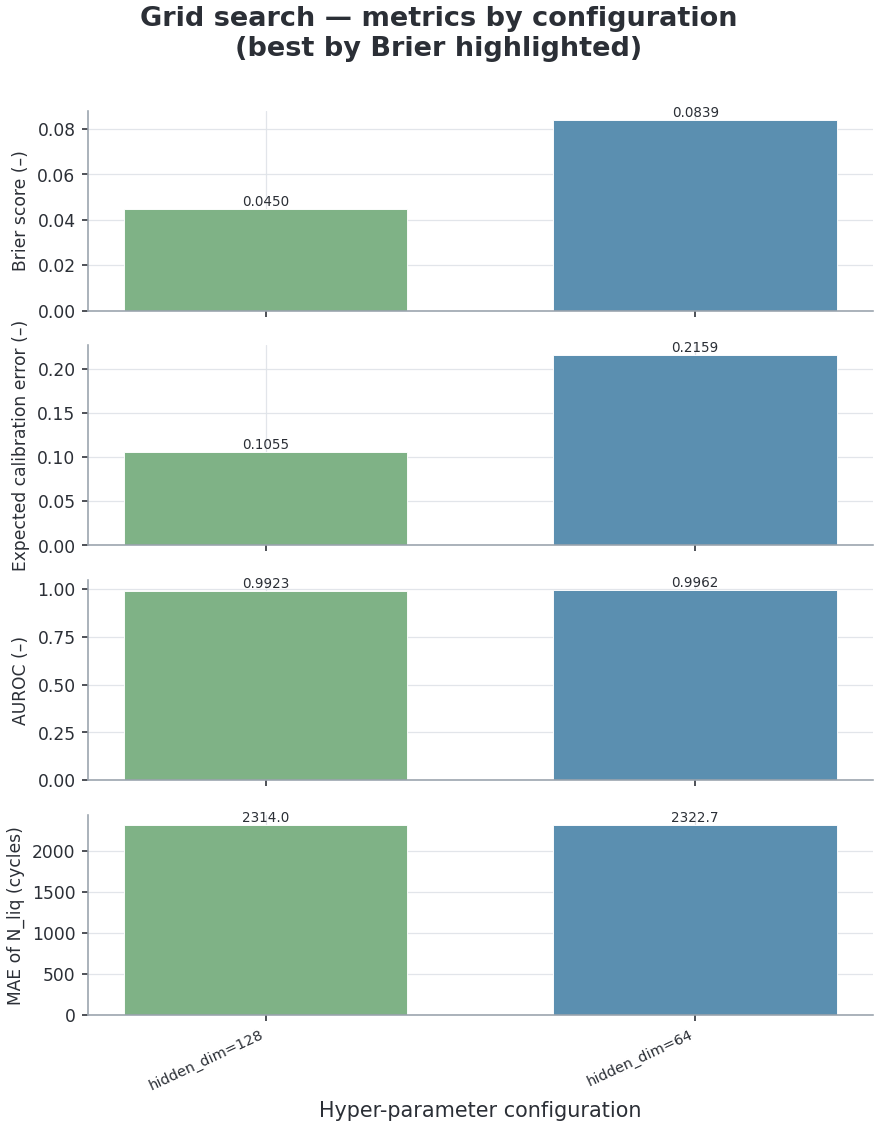

[GRU] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,96,0.1544,2391.7217,3806.5740,2.8558,3.3758,0.9846,0.9938,0.2123,0.0763,...,2.1882,1.0,2.8085,1.0,3.3465,0.1167,0.8309,0.2476,NaN,0.0
1,64,0.2114,2395.9556,3810.9995,2.9751,3.5127,0.8927,0.9371,0.2415,0.1772,...,2.2540,1.0,2.8930,1.0,3.4472,0.1167,0.8649,0.2572,NaN,0.0


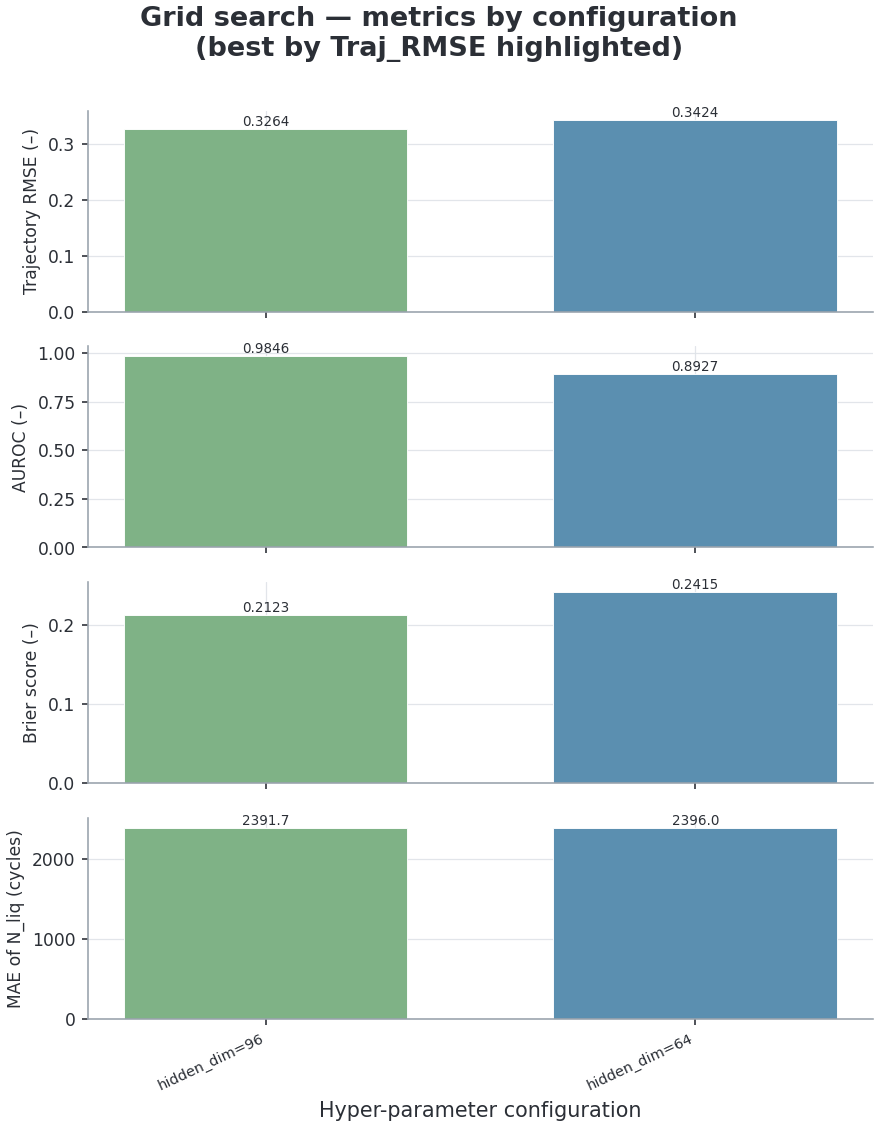

[TCN] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,96,0.2606,2394.7561,3809.3645,2.9392,3.4628,0.9376,0.9644,0.2466,0.118,...,2.3920,1.0,3.0701,1.0,3.6582,0.1167,0.9113,0.2635,NaN,0.0
1,64,0.3062,2392.4700,3806.7590,2.8783,3.3884,0.9628,0.9792,0.2413,0.080,...,2.5238,1.0,3.2392,1.0,3.8597,0.1167,0.9618,0.2754,NaN,0.0


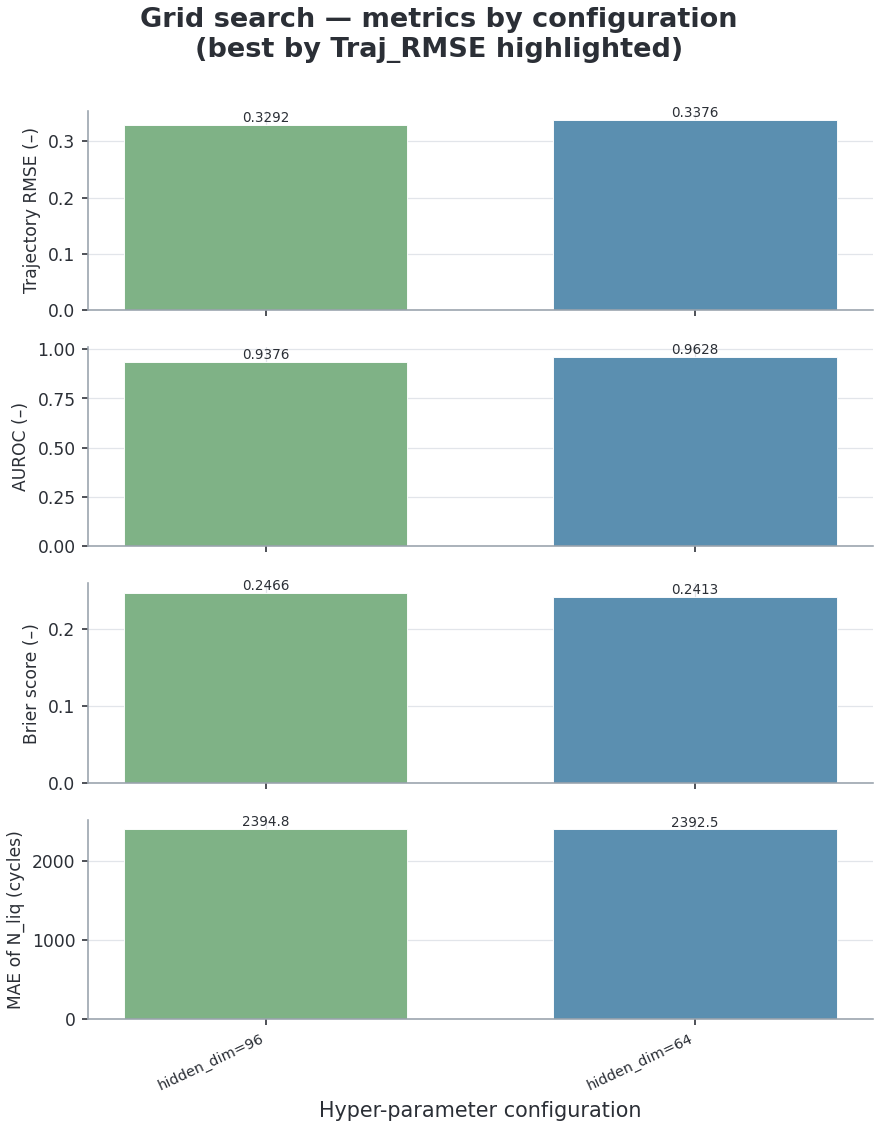

[LSTM] selection metric = Traj_RMSE | best = {'hidden_dim': 64}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,64,0.1977,2388.3574,3803.1038,2.7806,3.2883,0.9671,0.9819,0.2388,0.0563,...,2.2578,1.0,2.8979,1.0,3.453,0.1167,0.8566,0.2506,NaN,0.0
1,96,0.3071,2390.7805,3805.4253,2.8364,3.3476,0.9795,0.9901,0.2468,0.1211,...,2.5299,1.0,3.2470,1.0,3.869,0.1167,0.9595,0.2726,NaN,0.0


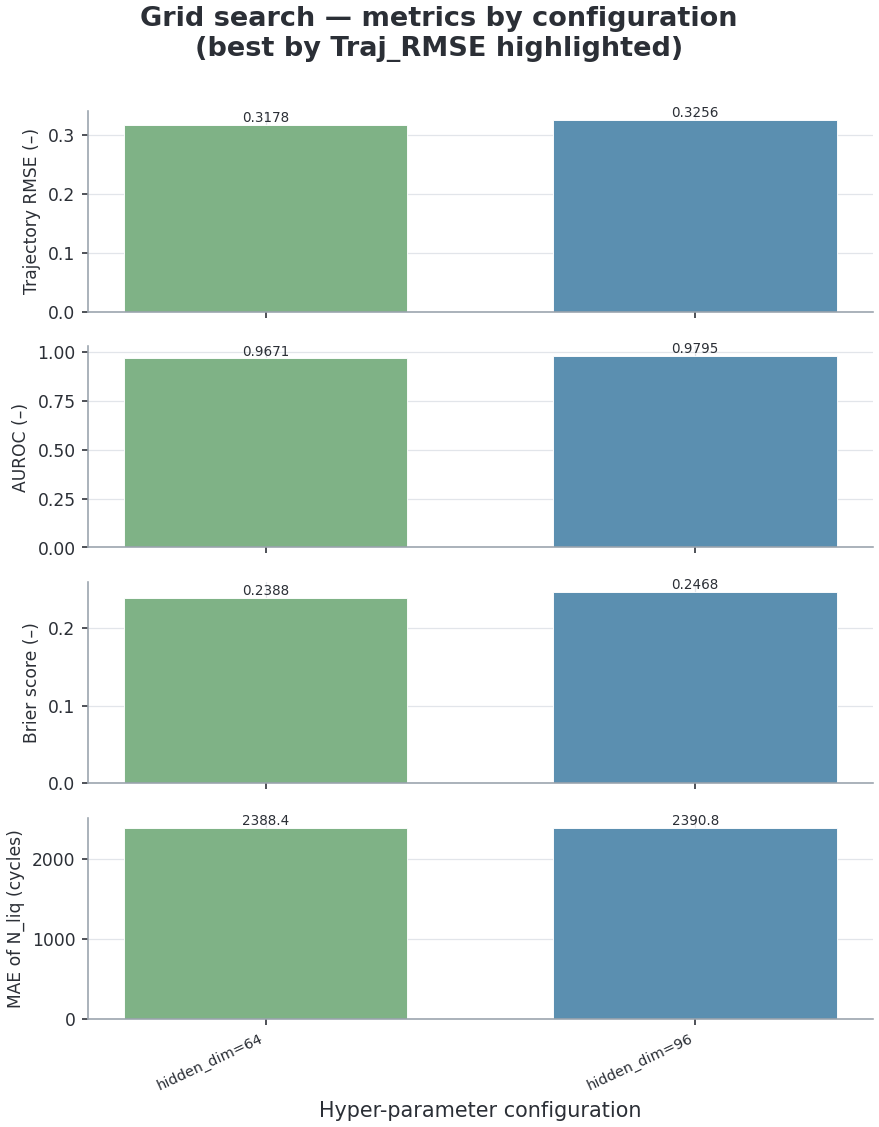

[Transformer] selection metric = Traj_RMSE | best = {'hidden_dim': 64}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,64,-0.5825,2396.5034,3812.1548,2.9794,3.5751,0.9534,0.9664,0.1901,0.3290,...,0.8899,0.9716,1.1422,0.9821,1.3609,0.0817,0.1085,0.1421,NaN,0.0
1,96,-0.5455,2369.4829,3791.3596,2.4782,3.0331,0.9897,0.9947,0.1554,0.3373,...,0.6286,0.8290,0.8068,0.8795,0.9614,0.0613,0.1807,0.1449,NaN,0.0


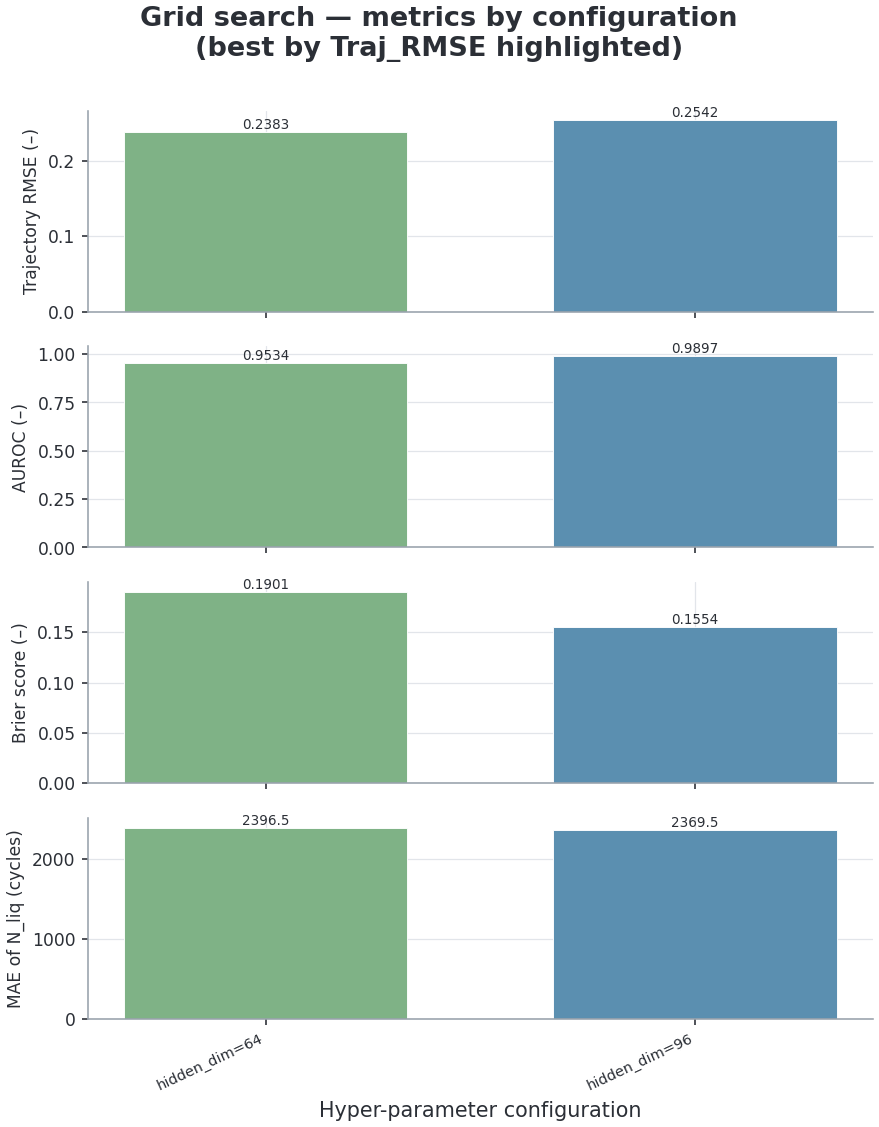

[FT-Transformer] selection metric = Brier | best = {'n_layers': 2}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,2,0.6930,2341.3010,3744.8696,2.1959,2.6032,0.9880,0.9927,0.2379,0.1423,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,3,0.7022,2352.8796,3761.3560,2.2863,2.7168,0.9915,0.9949,0.2405,0.1394,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


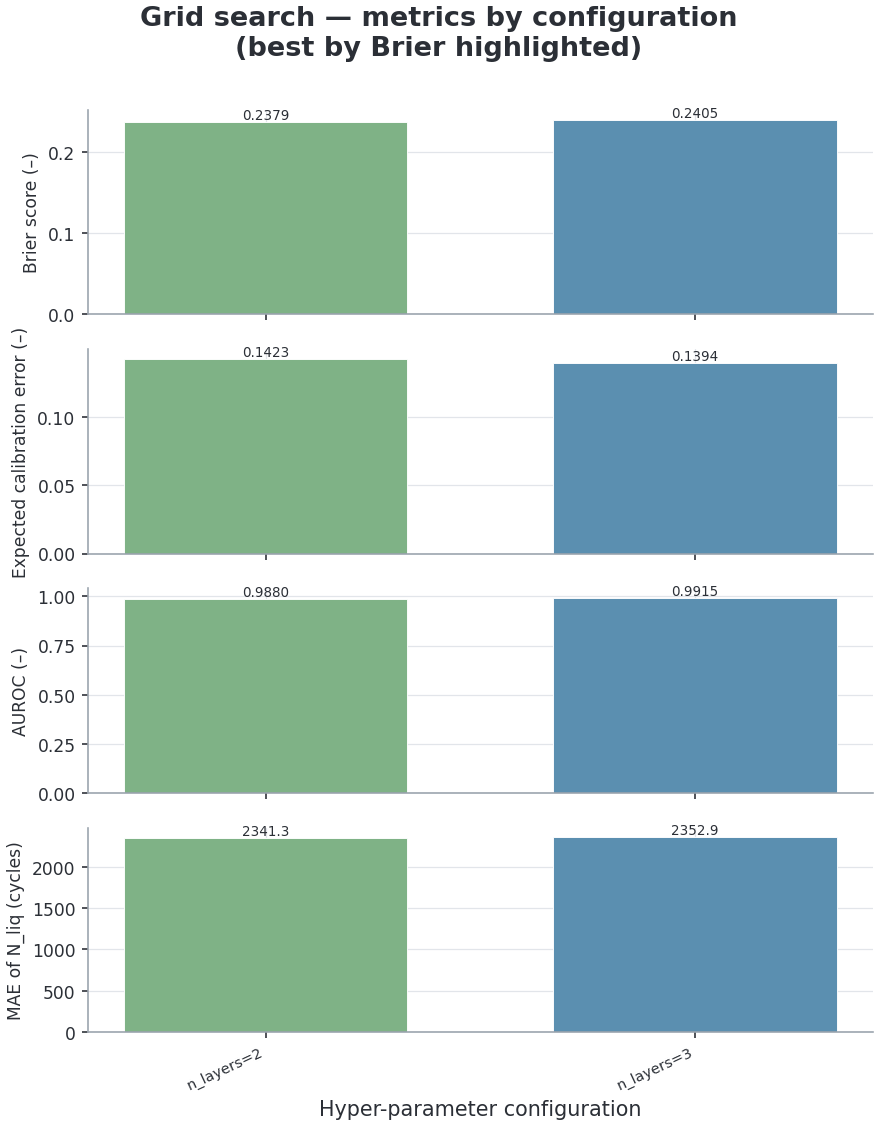

[PINN] selection metric = Traj_RMSE | best = {'hidden_dim': 96}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,96,-0.4796,2300.9563,3707.4485,1.8865,2.2809,0.9756,0.9866,0.1379,0.2749,...,0.5615,0.7562,0.7207,0.8545,0.8587,0.1240,0.2655,0.1566,NaN,0.0
1,64,-0.2291,2346.6194,3754.1372,2.2278,2.6561,0.9410,0.9647,0.2698,0.3293,...,1.0607,0.9994,1.3614,1.0000,1.6222,0.0745,0.4087,0.2114,NaN,0.0


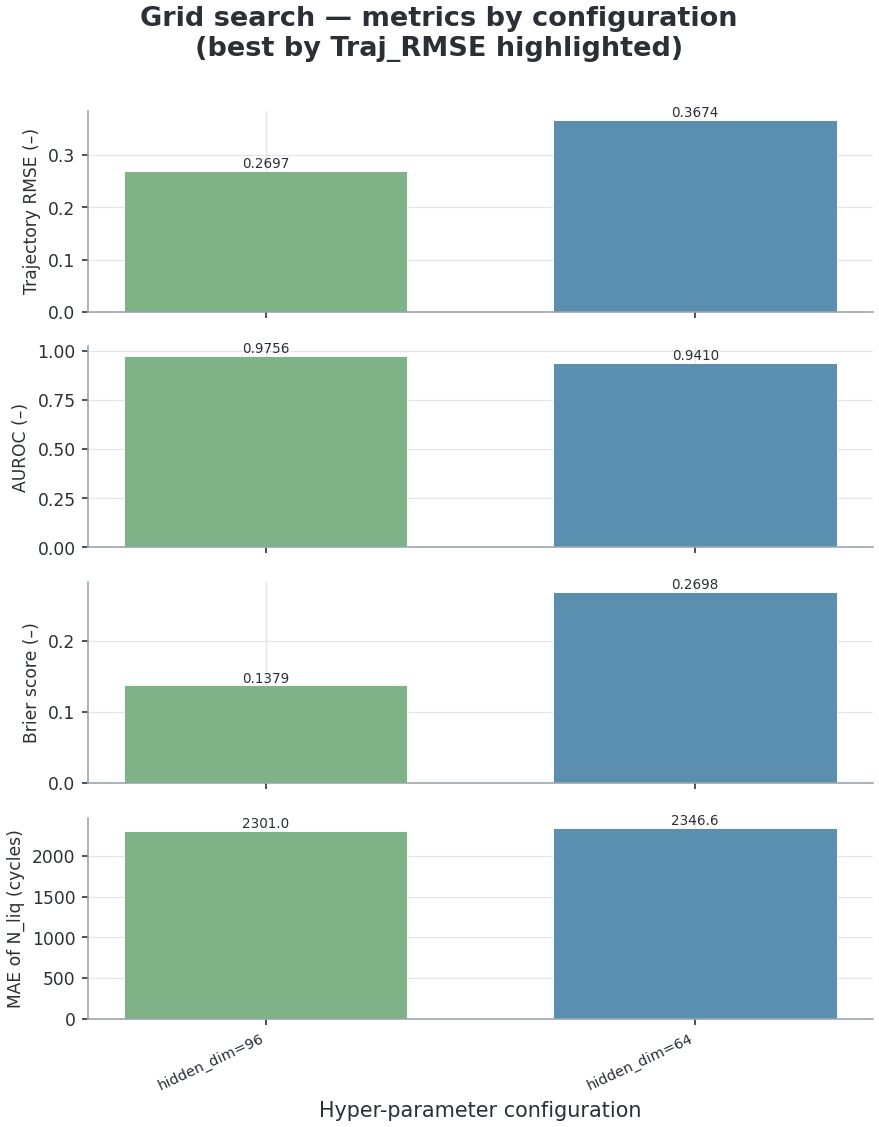

[DeepState] selection metric = Traj_RMSE | best = {'hidden_dim': 64}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,64,0.2353,2395.9727,3810.3359,2.9741,3.4989,0.9299,0.9632,0.2438,0.1270,...,2.2417,1.0,2.8771,1.0,3.4283,0.1167,0.8874,0.2732,NaN,0.0
1,96,0.2019,2390.0808,3804.5977,2.8200,3.3287,0.9774,0.9881,0.2286,0.3651,...,2.1821,1.0,2.8007,1.0,3.3372,0.1167,0.8674,0.2706,NaN,0.0


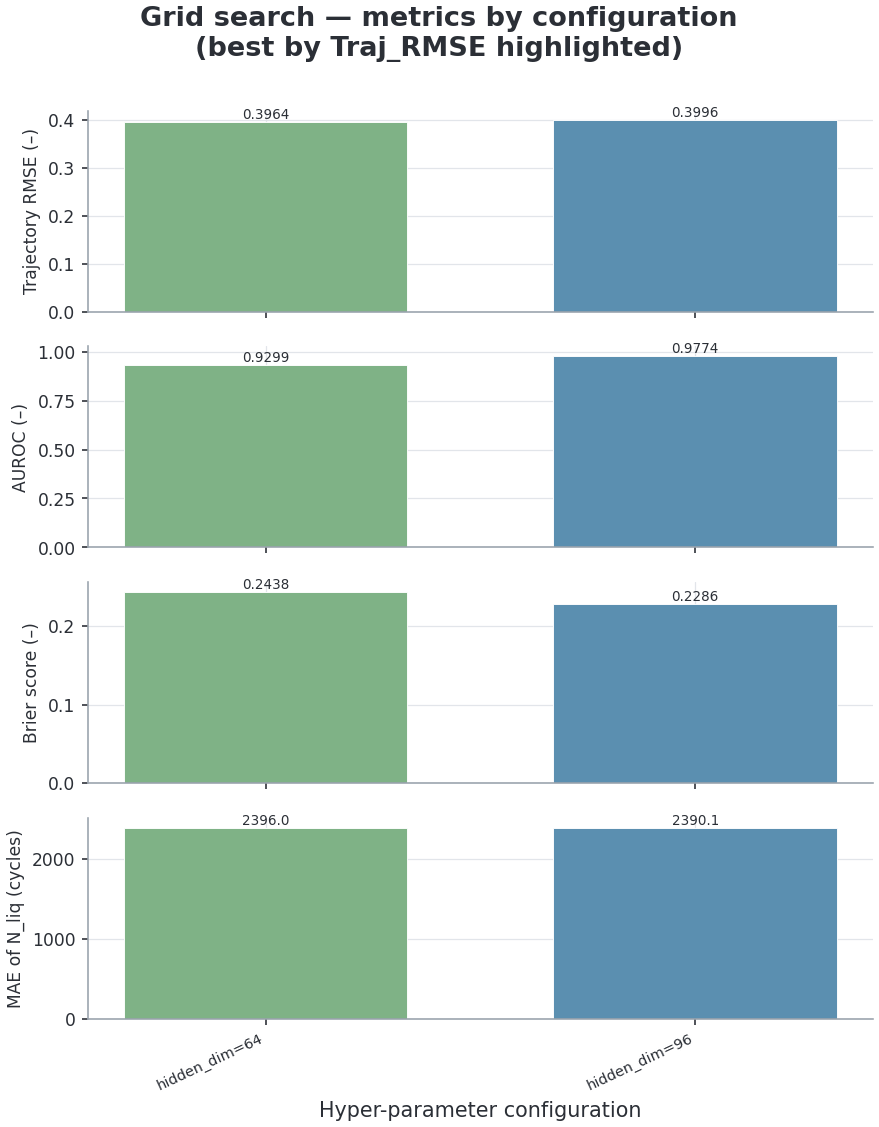

[RealNVP] selection metric = Traj_RMSE | best = {'n_layers': 6}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,6,4.9571,2388.4104,3800.2959,2.7842,3.2623,0.6568,0.7688,0.2453,0.1307,...,0.5440,0.5874,0.6982,0.7037,0.832,0.2941,0.6417,0.2066,NaN,0.0
1,4,5.7723,2389.1382,3806.4888,2.7994,3.3476,0.7252,0.8526,0.2421,0.1790,...,0.5434,0.5857,0.6974,0.7003,0.831,0.2958,0.6423,0.2070,NaN,0.0


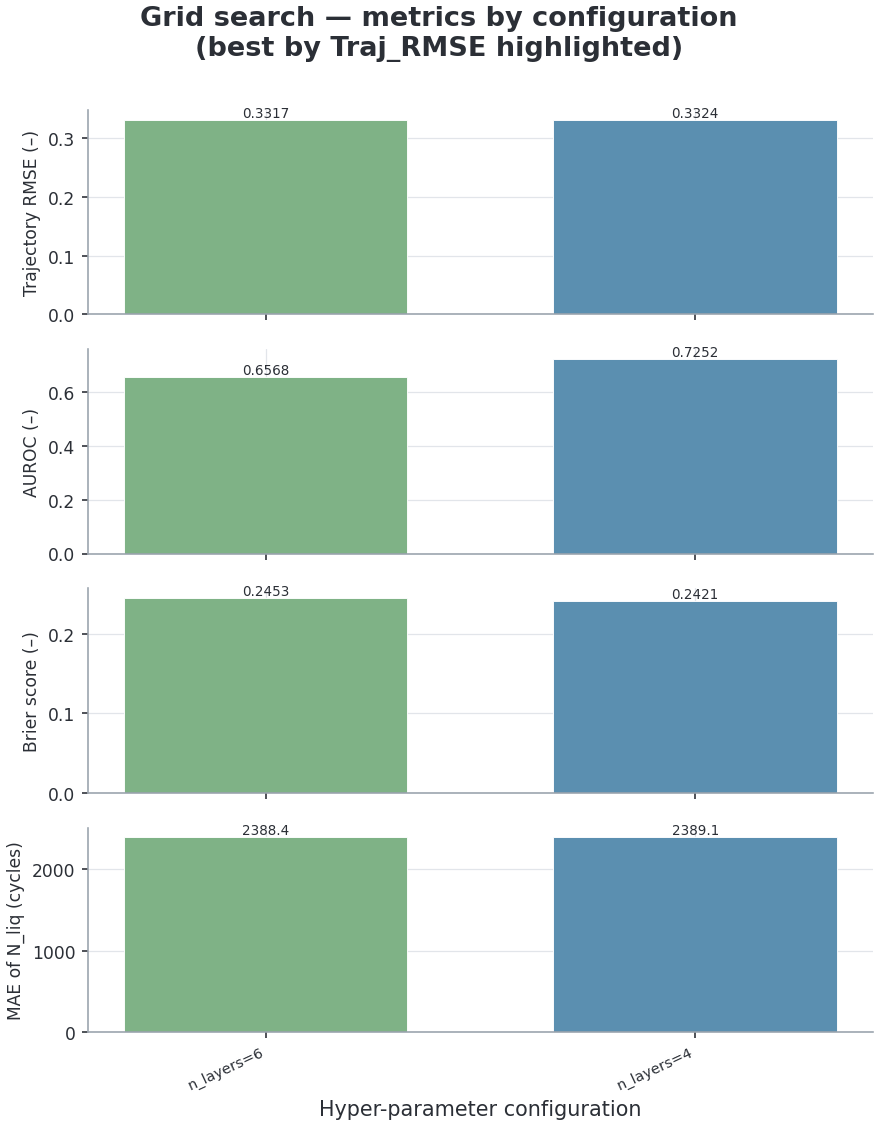

[Neural Spline Flow] selection metric = Traj_RMSE | best = {'n_layers': 5}


,n_layers,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,AUROC,AUPRC,Brier,ECE,...,Interval width@80%,Coverage@90%,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,Produces CRR
0,5,12.2607,2383.3765,3796.6287,2.6840,3.1732,0.8406,0.8467,0.2287,0.2968,...,0.5334,0.5976,0.6846,0.7131,0.8157,0.2831,0.5819,0.1991,NaN,0.0
1,4,12.2525,2385.5811,3800.3953,2.7243,3.2270,0.9919,0.9942,0.2049,0.3255,...,0.5329,0.5957,0.6840,0.7082,0.8151,0.2859,0.5939,0.2005,NaN,0.0


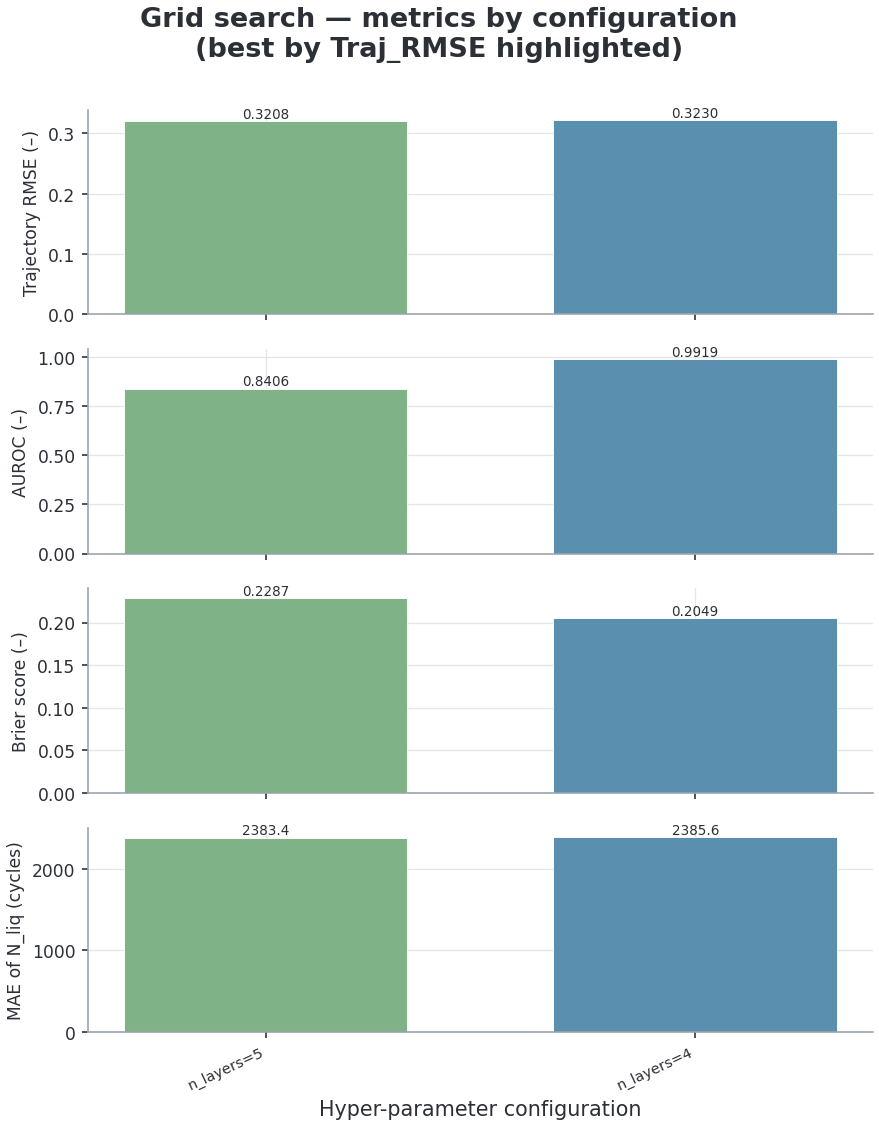

In [3]:
base_specs = {
    "mlp_risk": dict(display="MLP-Risk", cls=RiskMLP,
                     fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim),
                     grid={"hidden_dim": [64, 128]}, score="Brier",
                     metrics=["Brier", "ECE", "AUROC", "N_liq_MAE"]),
    "gru": dict(display="GRU", cls=GRUBaseline,
                fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "tcn": dict(display="TCN", cls=TCNBaseline,
                fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "lstm": dict(display="LSTM", cls=LSTMBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "transformer": dict(display="Transformer", cls=TransformerBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim, seq_len=config.seq_len),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "ft_transformer": dict(display="FT-Transformer", cls=FTTransformer,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim),
                 grid={"n_layers": [2, 3]}, score="Brier",
                 metrics=["Brier", "ECE", "AUROC", "N_liq_MAE"]),
    "pinn": dict(display="PINN", cls=PINNBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "deepstate": dict(display="DeepState", cls=DeepStateBaseline,
                 fixed=dict(static_dim=static_dim, seq_dim=seq_dim),
                 grid={"hidden_dim": [64, 96]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "realnvp": dict(display="RealNVP", cls=RealNVPFlow,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim, seq_len=config.seq_len),
                 grid={"n_layers": [4, 6]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
    "nsf": dict(display="Neural Spline Flow", cls=NeuralSplineFlow,
                 fixed=dict(static_dim=static_dim, prefix_dim=prefix_dim, seq_len=config.seq_len),
                 grid={"n_layers": [4, 5]}, score="Traj_RMSE",
                 metrics=["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE"]),
}

for name, spec in base_specs.items():
    cls, fixed, grid, score = spec["cls"], spec["fixed"], spec["grid"], spec["score"]
    res, best = grid_search(lambda p, cls=cls, fixed=fixed: cls(**fixed, **p),
                            grid, gs_train, gs_val, config, device, search_epochs=1, score_metric=score)
    write_hyperparams(MODELS_DIR, name, {"model_type": cls.__name__, "display_name": spec["display"],
                      "model_kwargs": {**fixed, **best}, "search": {"grid": grid, "score_metric": score, "best": best}})
    print(f"[{spec['display']}] selection metric = {score} | best = {best}")
    display(english_metric_table(res).round(4))
    show_grid_dashboard(res, grid, score, spec["metrics"], f"2_1_grid_search_{name}").show()

## Шаг 2. Финальное обучение по сохранённым гиперпараметрам

In [4]:
# Реестр классов всех baseline (имя класса -> класс) и число эпох по семействам
CLS = {RiskMLP.__name__: RiskMLP, GRUBaseline.__name__: GRUBaseline, TCNBaseline.__name__: TCNBaseline,
       LSTMBaseline.__name__: LSTMBaseline, TransformerBaseline.__name__: TransformerBaseline,
       FTTransformer.__name__: FTTransformer, PINNBaseline.__name__: PINNBaseline,
       DeepStateBaseline.__name__: DeepStateBaseline, RealNVPFlow.__name__: RealNVPFlow,
       NeuralSplineFlow.__name__: NeuralSplineFlow}
# PINN — физически-структурированная (больше эпох); остальные baseline — config.baseline_epochs
epoch_map = {name: (config.physics_epochs if name == "pinn" else config.baseline_epochs) for name in base_specs}
histories = {}
for name in base_specs:
    hp = read_hyperparams(MODELS_DIR, name)
    model = CLS[hp["model_type"]](**hp["model_kwargs"]).to(device)
    epochs = epoch_map[name]
    model, history = train_model(model, benchmark["train"], benchmark["val"], epochs=epochs,
                                 model_name=hp["display_name"], config=config, device=device, track_metrics=True)
    save_trained_model(model, MODELS_DIR, name, {**hp, "epochs": epochs, "learning_rate": config.learning_rate,
                       "weight_decay": config.weight_decay, "batch_size": config.batch_size, "seed": config.seed}, history)
    histories[hp["display_name"]] = history
    print("saved:", MODELS_DIR / name)

[MLP-Risk] эпоха 01 | обучение=0.5898 | валидация=0.2030 | val_AUROC=0.992


[MLP-Risk] эпоха 02 | обучение=0.1755 | валидация=0.0937 | val_AUROC=1.000


[MLP-Risk] эпоха 03 | обучение=0.0930 | валидация=0.0565 | val_AUROC=0.999


[MLP-Risk] эпоха 04 | обучение=0.0580 | валидация=0.0521 | val_AUROC=0.998


saved: /sessions/zealous-kind-sagan/mnt/liquefaction-ai/models/mlp_risk


...

[Neural Spline Flow] эпоха 01 | обучение=13.0361 | валидация=12.2607 | val_AUROC=0.841 | val_RMSE=0.3208


[Neural Spline Flow] эпоха 02 | обучение=12.4993 | валидация=11.9940 | val_AUROC=0.923 | val_RMSE=0.3038


[Neural Spline Flow] эпоха 03 | обучение=12.3085 | валидация=11.8033 | val_AUROC=0.960 | val_RMSE=0.2846


[Neural Spline Flow] эпоха 04 | обучение=12.1402 | валидация=11.6984 | val_AUROC=0.974 | val_RMSE=0.2674


saved: /sessions/zealous-kind-sagan/mnt/liquefaction-ai/models/nsf


## Кривые обучения с метриками

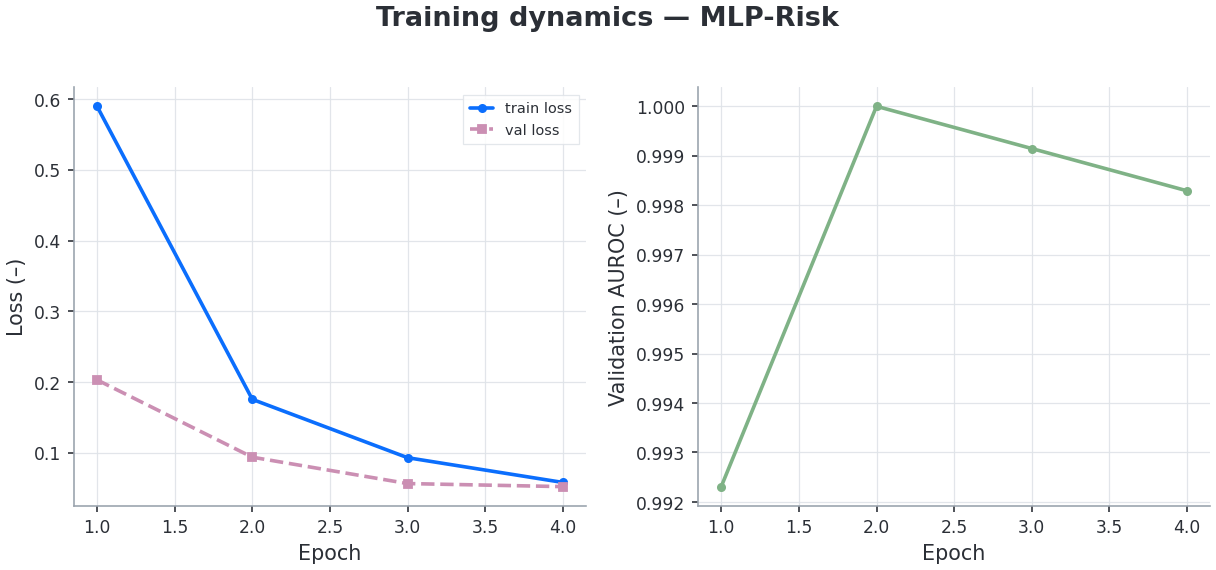

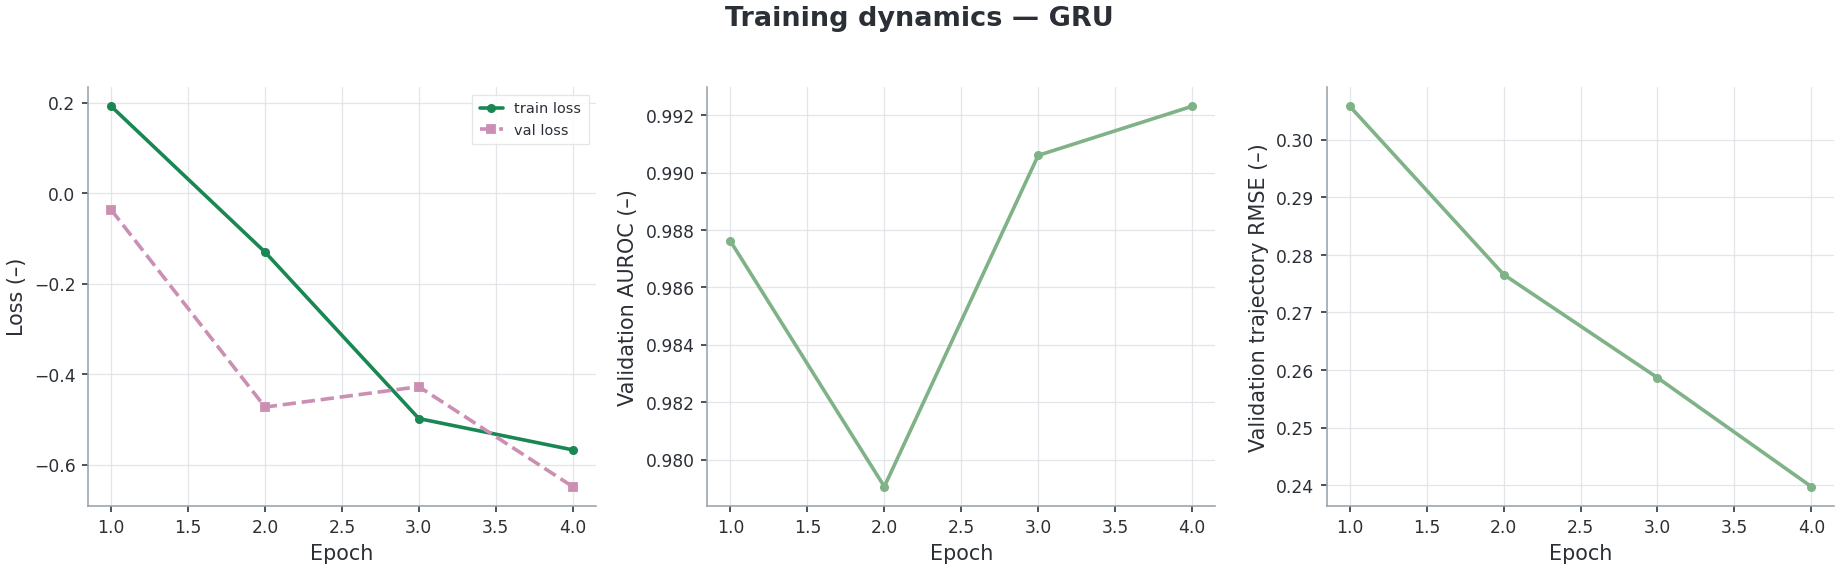

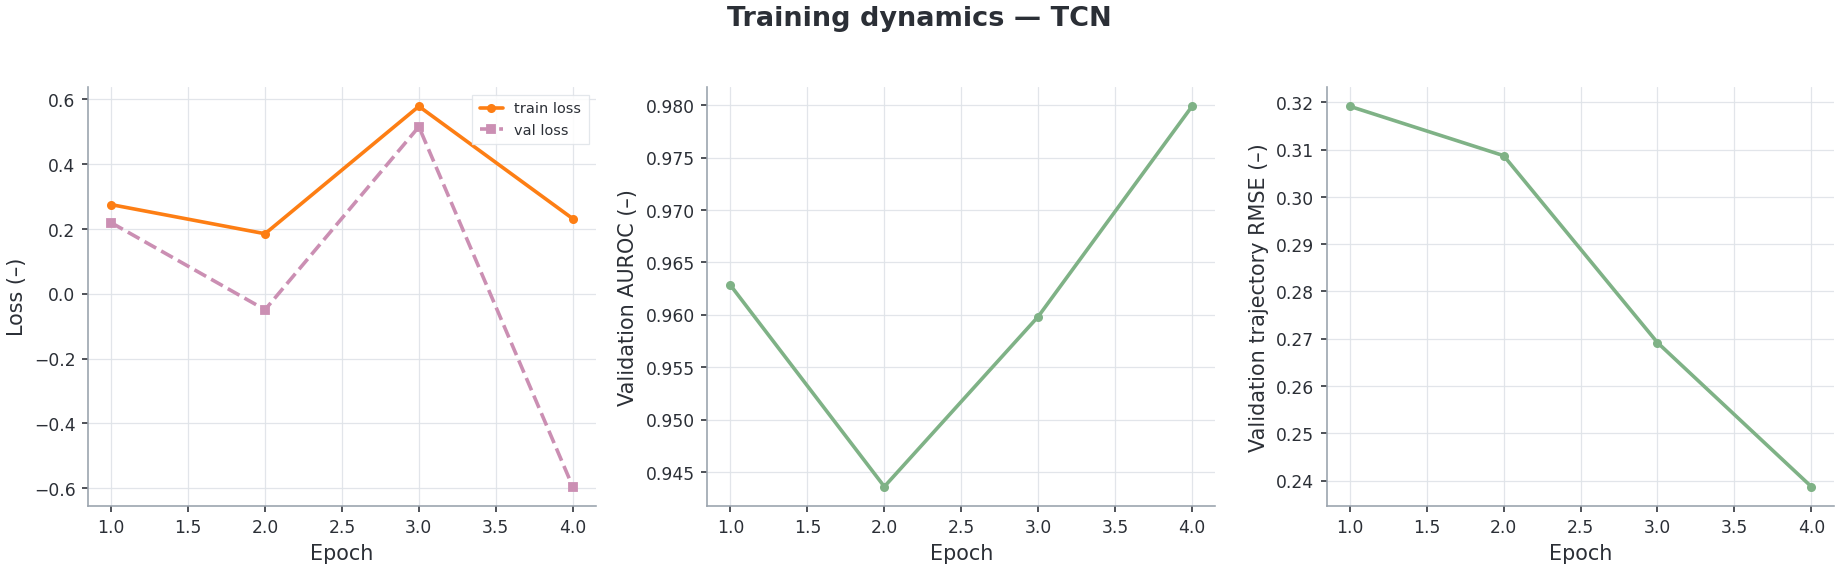

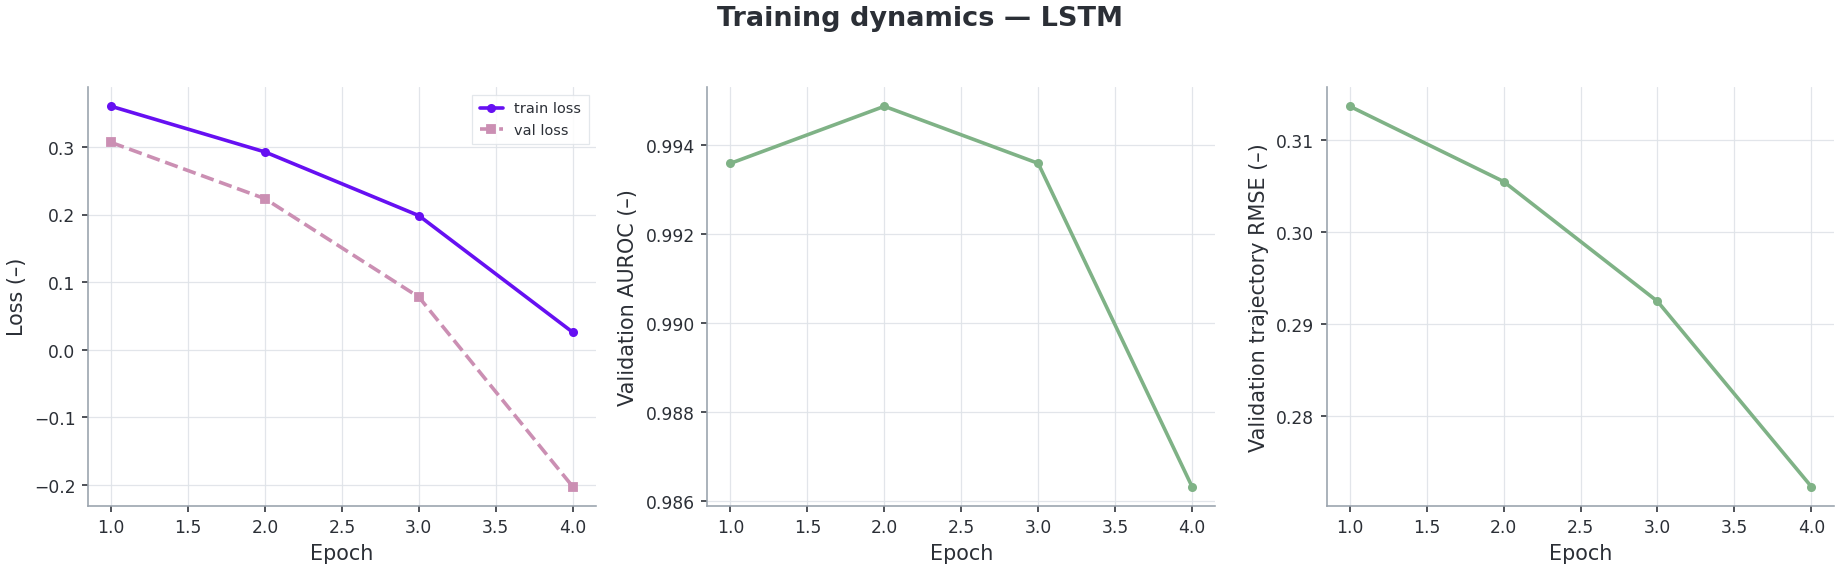

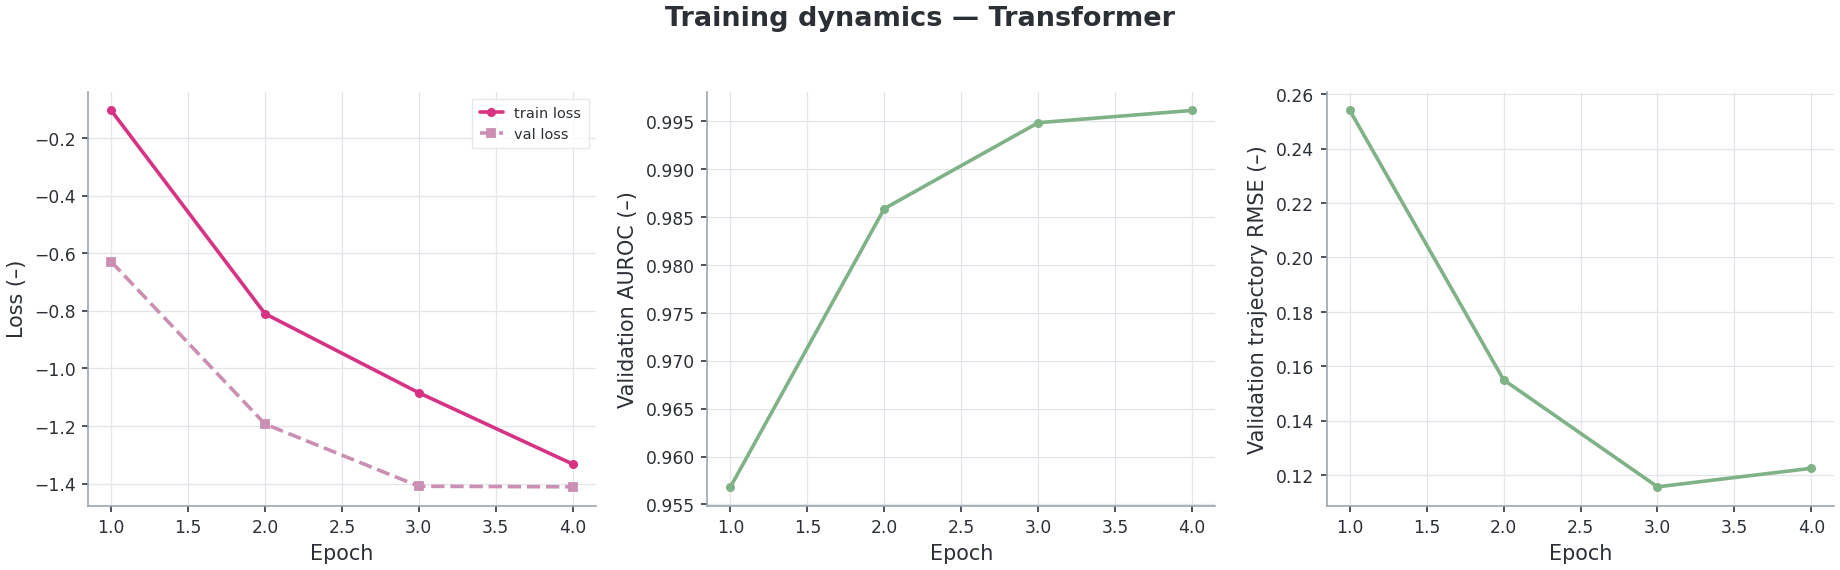

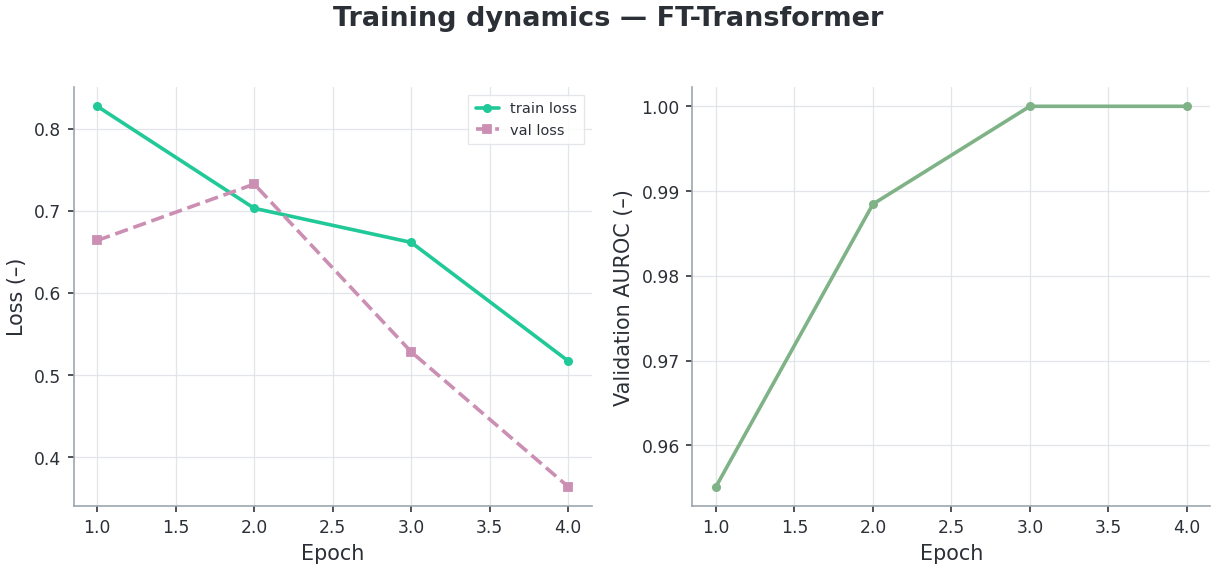

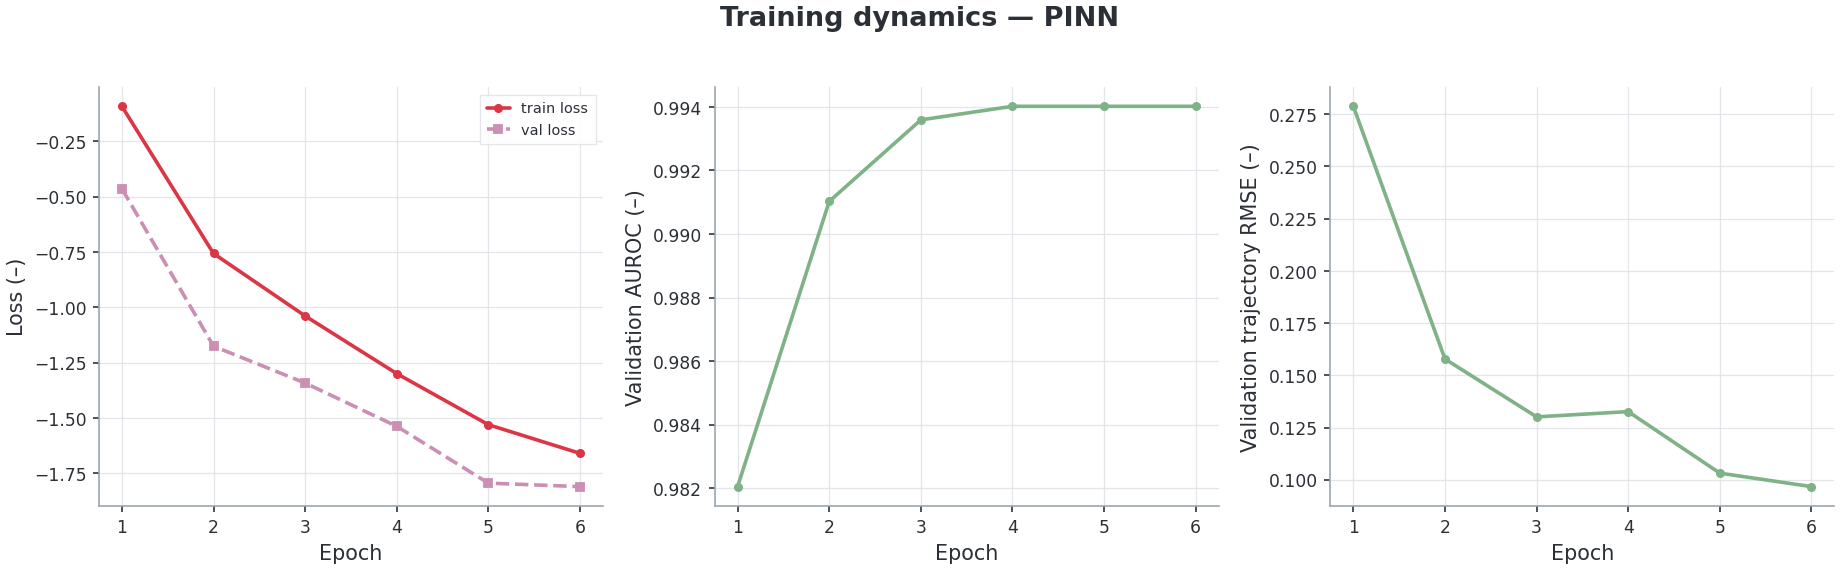

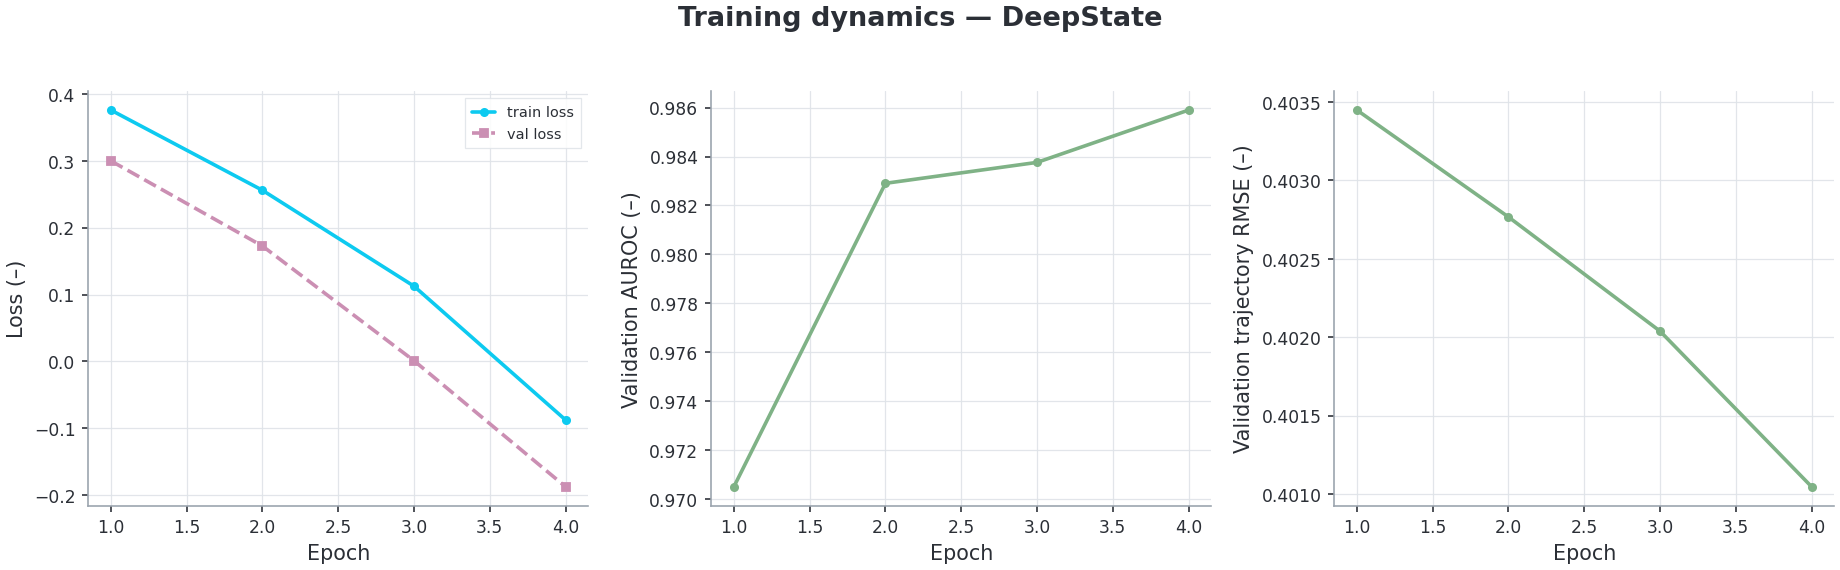

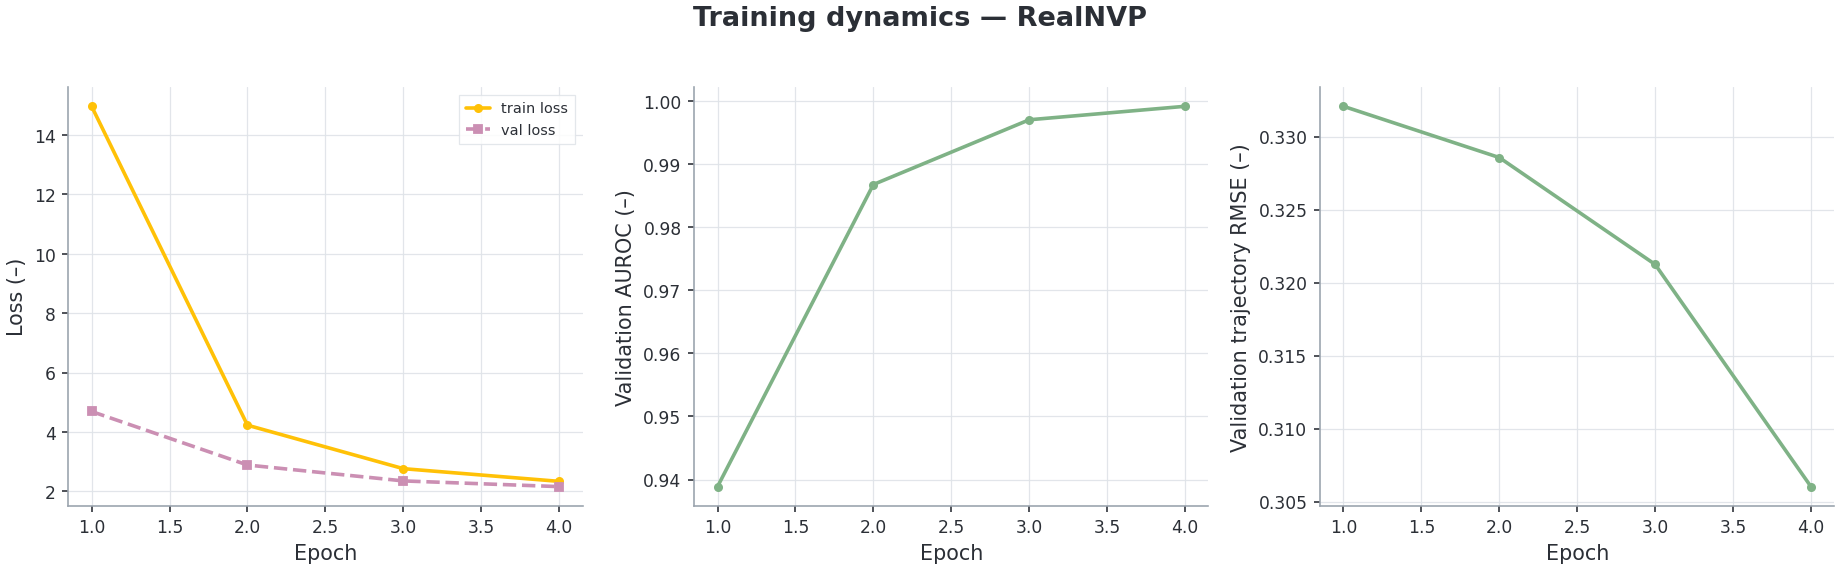

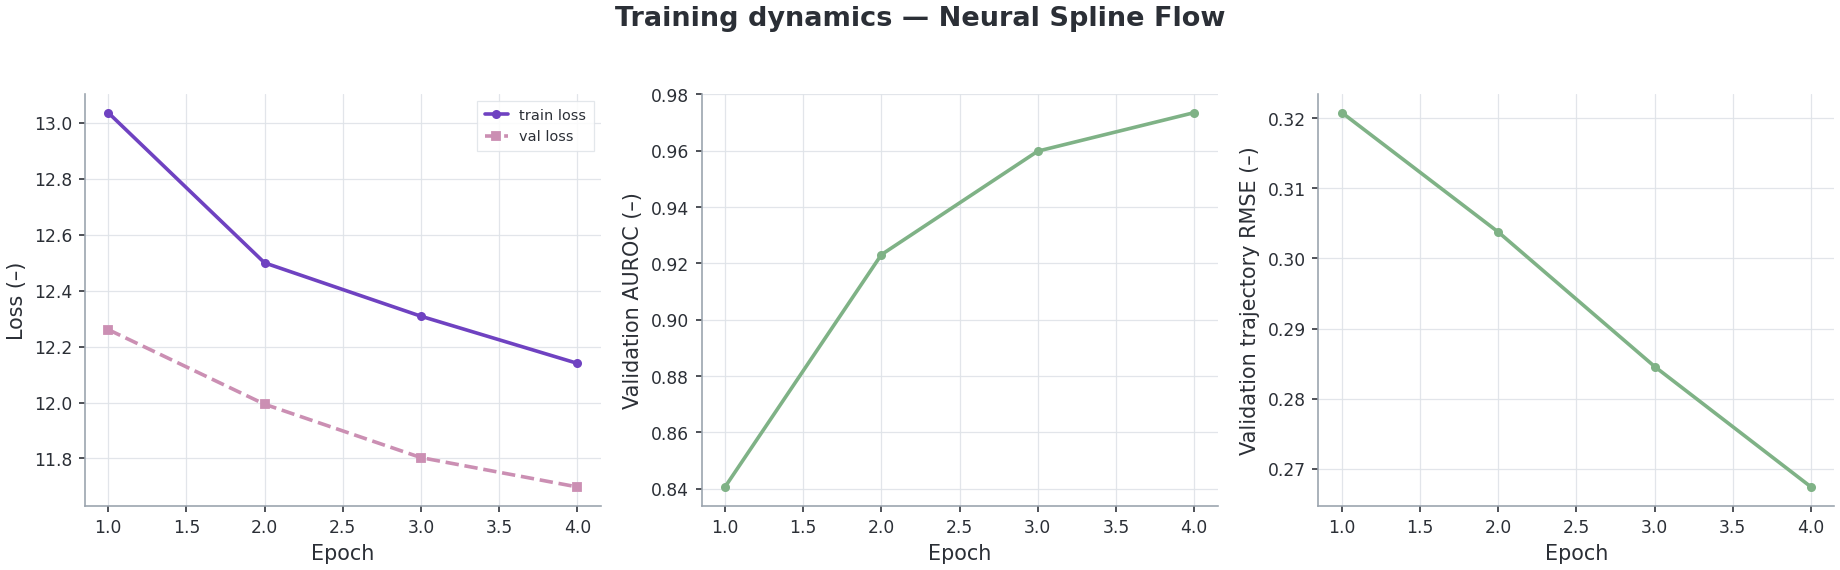

In [5]:
palette = ["#0b6efd", "#198754", "#fd7e14", "#6610f2", "#d63384", "#20c997", "#dc3545", "#0dcaf0", "#ffc107", "#6f42c1"]
colors = {disp: palette[i % len(palette)] for i, disp in enumerate(histories)}
for disp, hist in histories.items():
    training_dashboard(hist, title=f"Training dynamics — {disp}", model_color=colors[disp],
                       save=SAVE_FIGS, fig_id=f"2_1_training_{disp.lower().replace('-', '_')}").show()

## Итог

Базовые модели подобраны grid search (с выбором метрики) и обучены. Дальше — **2.2 DPI-Flow**.

In [6]:
# --- CatBoost (табличный градиентный бустинг) ---
# Не нейросеть, поэтому обучается своим .fit (не train_model) и сохраняется нативно.
cb = CatBoostBaseline(static_dim, prefix_dim).fit(benchmark["train"], benchmark["val"])
cb.save(MODELS_DIR, "catboost")
write_hyperparams(MODELS_DIR, "catboost", {"model_type": "CatBoostBaseline", "display_name": "CatBoost",
                  "model_kwargs": dict(static_dim=static_dim, prefix_dim=prefix_dim)})
print("saved:", MODELS_DIR / "catboost")

saved: /sessions/zealous-kind-sagan/mnt/liquefaction-ai/models/catboost
